In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import mappy as mp
import requests

from subset_alu_seqs import *
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
from analysis_utils import *

/home/kvandeyn/.conda/envs/tdb/lib/python3.10/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


In [ ]:
final_labels = pd.read_csv('../feature_generation_scripts/final_manuscript_labels.tsv', sep='\t')
# switch the DM2 locusID to its original locusID cause it got assigned differently 
final_labels.loc[final_labels['disease_id'] == 'DM2', 'LocusID'] = 'original_LocusID'
final_labels

/tmp/ipykernel_2342904/4189327670.py:1: DtypeWarning: Columns (3,9,22,23) have mixed types. Specify dtype option on import or set low_memory=False.
  final_labels = pd.read_csv('final_labels_manuscript.tsv', sep='\t')


,start,end,LocusID,mei_id,start_mei,end_mei,mei_family,mei_subfamily,orientation,divergence,...,terminal_label,GencodeGeneRegion,RefseqGeneRegion,ManeGeneRegion,disease_id,genomic_annotation,keep_rel_pos,mei_family_plot,simple_motif,base_composition
0,26931,26941,26.0,19.0,26791.0,27053.0,SINE_Alu,AluSp,+,9.5,...,internal,intergenic,intron,intergenic,non_disease_associated,intron,True,Alu,ACC,AC
1,27862,27872,27.0,21.0,27833.0,28014.0,SINE_MIR,MIRb,C,33.6,...,internal,intergenic,intron,intergenic,non_disease_associated,intron,True,SINE_MIR,ATC,ACT
2,28245,28255,28.0,22.0,28151.0,28302.0,SINE_MIR,MIR,C,32.0,...,internal,intergenic,intron,intergenic,non_disease_associated,intron,True,SINE_MIR,ACT,ACT
3,30866,30892,34.0,26.0,30694.0,30848.0,LTR_ERVL-MaLR,MLT1A,+,18.7,...,3'terminal,intron,intron,intergenic,non_disease_associated,intron,True,LTR_ERVL-MaLR,AG,AG
4,30934,30948,36.0,26.0,30953.0,31131.0,LTR_ERVL-MaLR,MLT1A,+,18.7,...,5'terminal,intron,intron,intergenic,non_disease_associated,intron,True,LTR_ERVL-MaLR,AG,AG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2430013,56694117,56694136,4542235.0,non_mei,NaN,NaN,non_mei,non_mei,non_mei,non_mei,...,non_mei,intergenic,intergenic,intergenic,NaN,NaN,True,non-MEI,AATGG,AGT
2430014,56694220,56694236,4542236.0,non_mei,NaN,NaN,non_mei,non_mei,non_mei,non_mei,...,non_mei,intergenic,intergenic,intergenic,NaN,NaN,True,non-MEI,AATGG,AGT
2430015,56694332,56694350,4542237.0,non_mei,NaN,NaN,non_mei,non_mei,non_mei,non_mei,...,non_mei,intergenic,intergenic,intergenic,NaN,NaN,True,non-MEI,AATGG,AGT
2430016,56694378,56694395,4542238.0,non_mei,NaN,NaN,non_mei,non_mei,non_mei,non_mei,...,non_mei,intergenic,intergenic,intergenic,NaN,NaN,True,non-MEI,AATGG,AGT


# Read and combine the outputs from Alu position mapping scripts

In [4]:
full_corrected_df = pd.read_csv("/nfs/boylelab_turbo/kvandeyn/MEI_STR/data/TR_catalog_HPRC/alu_lineage_data/alu_sets/internal_between_fragments_full_length_input_consensus_relative_start.txt", sep = "\t")
truncated_corrected_df = pd.read_csv("/nfs/boylelab_turbo/kvandeyn/MEI_STR/data/TR_catalog_HPRC/alu_lineage_data/alu_sets/internal_between_fragments_truncated_input_consensus_relative_start.txt", sep = "\t")
print(full_corrected_df.drop_duplicates(subset=["LocusID"]).shape)
full_corrected_df = full_corrected_df.drop_duplicates(subset=["LocusID"])
truncated_corrected_df = truncated_corrected_df.drop_duplicates(subset=["LocusID"])
# use just the upstream fragment alignments
full_corrected_df = pd.read_csv("/nfs/boylelab_turbo/kvandeyn/MEI_STR/data/TR_catalog_HPRC/alu_lineage_data/alu_sets/upstream_frag_only_input_consensus_relative_start.txt", sep = "\t")
print(full_corrected_df.shape)
print(truncated_corrected_df.shape)

# merge both with final_labels on LocusID to get the internal_external column
full_corrected_df = full_corrected_df.merge(final_labels[["LocusID","internal_external","str_motif","terminal_label","STR_classification","disease_id","mei_family"]], on="LocusID", how="left").dropna(subset=["internal_external"])
truncated_corrected_df = truncated_corrected_df.merge(final_labels[["LocusID","internal_external","str_motif","terminal_label","STR_classification","disease_id","mei_family"]], on="LocusID", how="left").dropna(subset=["internal_external"])

# get simple motifs
full_corrected_df["simple_motif"] = full_corrected_df["str_motif"].apply(SequenceAttributes.get_simple_motif)
truncated_corrected_df["simple_motif"] = truncated_corrected_df["str_motif"].apply(SequenceAttributes.get_simple_motif)

# add one to all of these consensus_relative_start since I forgot to adjust for TRID in these and I did in the others
full_corrected_df["consensus_relative_start"] = full_corrected_df["consensus_relative_start"] + 1
truncated_corrected_df["consensus_relative_start"] = truncated_corrected_df["consensus_relative_start"] + 1

full_corrected_df

(2506, 12)
(2506, 10)
(1416, 10)


,chrom,start,end,LocusID,start_mei,end_mei,mei_id,mei_subfamily,orientation,consensus_relative_start,internal_external,str_motif,terminal_label,STR_classification,disease_id,mei_family,simple_motif
0,chr8,735310,735365,2083543.0,735178,735310,AluSc5.chr8:735178-735310,AluSc5,+,139.0,internal,ATA,internal,internal_between_fragments,non_disease_associated,SINE_Alu,AAT
1,chr20,737623,737660,4050606.0,737494,737624,AluSq2.chr20:737494-737624,AluSq2,+,133.0,internal,AAT,internal,internal_between_fragments,non_disease_associated,SINE_Alu,AAT
2,chr9,948902,948945,2300668.0,948779,948903,AluSx1.chr9:948779-948903,AluSx1,+,133.0,internal,AAT,internal,internal_between_fragments,non_disease_associated,SINE_Alu,AAT
3,chr19,1191065,1191093,3934403.0,1190941,1191057,AluSx1.chr19:1190941-1191057,AluSx1,+,133.0,internal,AAAAT,internal,internal_between_fragments,non_disease_associated,SINE_Alu,AAAAT
4,chr1,1653824,1653863,2476.0,1653702,1653825,AluSx.chr1:1653702-1653825,AluSx,+,126.0,internal,AC,internal,internal_between_fragments,non_disease_associated,SINE_Alu,AC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2501,chr1,396900,396941,476.0,396942,397059,AluSg.chr1:396942-397059,AluSg,-,121.0,internal,GT,internal,internal_between_fragments,NaN,SINE_Alu,AC
2502,chr20,338576,338613,4049819.0,338625,338745,AluSx.chr20:338625-338745,AluSx,-,137.0,internal,TG,internal,internal_between_fragments,non_disease_associated,SINE_Alu,AC
2503,chr18,151323,151353,3820090.0,151354,151475,AluJr.chr18:151354-151475,AluJr,-,123.0,internal,TTTTG,internal,internal_between_fragments,non_disease_associated,SINE_Alu,AAAAC
2504,chr8,110637,110676,2082737.0,110677,110796,AluSg.chr8:110677-110796,AluSg,-,123.0,internal,GT,internal,internal_between_fragments,NaN,SINE_Alu,AC


In [5]:
# read truncated position results and merge with final_labels
truncated = "/nfs/boylelab_turbo/kvandeyn/MEI_STR/data/TR_catalog_HPRC/alu_lineage_data/alu_sets/all_truncated_alus_with_strs_consensus_relative_start.txt"
truncated_df = pd.read_csv(truncated, sep="\t")

# merge on final_labels to get the internal_external labels as well as the updated mei coordinates in case they changed
truncated_orig_labels = truncated_df.merge(final_labels[["LocusID","start_mei","end_mei","internal_external","str_motif","TRID","terminal_label","STR_classification","disease_id","mei_family"]], on="LocusID", how="left",suffixes=("_orig","_final"))

# print how many start_mei_orig and end_mei_orig are not the same as start_mei_final and end_mei_final
print("Number of start_mei_orig not equal to start_mei_final:", (truncated_orig_labels["start_mei_orig"] != truncated_orig_labels["start_mei_final"]).sum())
print("Number of end_mei_orig not equal to end_mei_final:", (truncated_orig_labels["end_mei_orig"] != truncated_orig_labels["end_mei_final"]).sum())

# what are these sums without including LocusIDs in full_corrected_df or truncated_corrected_df
print("Number of start_mei_orig not equal to start_mei_final without LocusIDs in full_corrected_df or truncated_corrected_df:", (truncated_orig_labels["start_mei_orig"] != truncated_orig_labels["start_mei_final"]).sum() - (truncated_orig_labels["LocusID"].isin(full_corrected_df["LocusID"]) | truncated_orig_labels["LocusID"].isin(truncated_corrected_df["LocusID"])).sum())
print("Number of end_mei_orig not equal to end_mei_final without LocusIDs in full_corrected_df or truncated_corrected_df:", (truncated_orig_labels["end_mei_orig"] != truncated_orig_labels["end_mei_final"]).sum() - (truncated_orig_labels["LocusID"].isin(full_corrected_df["LocusID"]) | truncated_orig_labels["LocusID"].isin(truncated_corrected_df["LocusID"])).sum())


# assign columns start_mei and end_mei to start_mei_final and end_mei_final

# only keep the rows with LocusID not in full_corrected_df or truncated_corrected_df
truncated_orig_labels = truncated_orig_labels[~truncated_orig_labels["LocusID"].isin(full_corrected_df["LocusID"]) & ~truncated_orig_labels["LocusID"].isin(truncated_corrected_df["LocusID"])].dropna(subset=["internal_external","start_mei_final","end_mei_final"])
truncated_orig_labels["start_mei"] = truncated_orig_labels["start_mei_final"].astype(int)
truncated_orig_labels["end_mei"] = truncated_orig_labels["end_mei_final"].astype(int)

# get the simple_motif column
truncated_orig_labels["simple_motif"] = truncated_orig_labels["str_motif"].apply(SequenceAttributes.get_simple_motif)
truncated_orig_labels


Number of start_mei_orig not equal to start_mei_final: 2862
Number of end_mei_orig not equal to end_mei_final: 4938
Number of start_mei_orig not equal to start_mei_final without LocusIDs in full_corrected_df or truncated_corrected_df: -274
Number of end_mei_orig not equal to end_mei_final without LocusIDs in full_corrected_df or truncated_corrected_df: 1802


,chrom,start,end,LocusID,start_mei_orig,end_mei_orig,mei_id,mei_subfamily,orientation,consensus_relative_start,...,internal_external,str_motif,TRID,terminal_label,STR_classification,disease_id,mei_family,start_mei,end_mei,simple_motif
0,chr1,35488.0,35507.0,46.0,35367,35493,AluJr.chr1:35367-35493,AluJr,+,122.0,...,external,AAAT,1-35488-35507-AAAT,3'terminal,external_upstream_overlap,non_disease_associated,SINE_Alu,35367,35493,AAAT
1,chr1,129540.0,129549.0,197.0,129383,129675,AluSx.chr1:129383-129675,AluSx,-,165.0,...,internal,CAC,1-129540-129549-CAC,internal,internal_fully_overlapped,non_disease_associated,SINE_Alu,129383,129675,ACC
2,chr1,143168.0,143184.0,215.0,143165,143272,AluJb.chr1:143165-143272,AluJb,-,298.0,...,internal,TATTT,1-143168-143184-TATTT,3'terminal,internal_fully_overlapped,non_disease_associated,SINE_Alu,143165,143272,AAAAT
3,chr1,147074.0,147083.0,223.0,147060,147161,AluJb.chr1:147060-147161,AluJb,-,146.0,...,internal,CAC,1-147074-147083-CAC,internal,internal_fully_overlapped,NaN,SINE_Alu,147060,147161,ACC
4,chr1,147461.0,147475.0,225.0,147476,147535,AluJb.chr1:147476-147535,AluJb,-,83.0,...,external,AAC,1-147461-147475-AAC,3'terminal,external_downstream_proximity,NaN,SINE_Alu,147476,147535,AAC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77442,chrY,26369991.0,26370000.0,4541384.0,26369878,26370158,AluJr.chrY:26369878-26370158,AluJr,+,147.0,...,internal,TGG,Y-26369991-26370000-TGG,internal,internal_fully_overlapped,NaN,SINE_Alu,26369878,26370158,ACC
77444,chrY,26482855.0,26482864.0,4541622.0,26482806,26483001,AluJo.chrY:26482806-26483001,AluJo,-,146.0,...,internal,CAC,Y-26482855-26482864-CAC,internal,internal_fully_overlapped,NaN,SINE_Alu,26482806,26483001,ACC
77445,chrY,26573674.0,26573689.0,4541784.0,26573703,26573948,AluJo.chrY:26573703-26573948,AluJo,-,327.0,...,external,TTCT,Y-26573674-26573689-TTCT,3'terminal,external_downstream_proximity,NaN,SINE_Alu,26573703,26573948,AAAG
77446,chrY,26534646.0,26534656.0,4541725.0,26534537,26534794,AluSg.chrY:26534537-26534794,AluSg,+,147.0,...,internal,TGG,Y-26534646-26534656-TGG,internal,internal_fully_overlapped,NaN,SINE_Alu,26534537,26534794,ACC


In [6]:
# do the same for the full and context set
full_orig_df = pd.read_csv("/nfs/boylelab_turbo/kvandeyn/MEI_STR/data/random_forest_features/alu_str_features_06192025/full_alu_dists_1kb_gap_reviosion_consensus_relative_start.txt",sep="\t")

full_orig_df = full_orig_df.merge(final_labels[["LocusID","start_mei","end_mei","internal_external","str_motif","TRID","terminal_label","STR_classification","disease_id","mei_family"]], on="LocusID", how="left",suffixes=("","_final")).dropna(subset=["internal_external"])

# get the simple_motif 
# drop rows where "," is in the str_motif
full_orig_df = full_orig_df[~full_orig_df["str_motif"].str.contains(",")]
full_orig_df["simple_motif"] = full_orig_df["str_motif"].apply(SequenceAttributes.get_simple_motif)

full_orig_df

,chrom,start,end,LocusID,chrom_mei,start_mei,end_mei,mei_id,mei_subfamily,orientation,...,start_mei_final,end_mei_final,internal_external,str_motif,TRID,terminal_label,STR_classification,disease_id,mei_family,simple_motif
0,chr1,30867,30892,34.0,chr1,31436,31733,AluJo.chr1:31436-31733,AluJo,+,...,30694.0,30848.0,external,CT,1-30867-30892-CT,3'terminal,external_upstream_proximity,non_disease_associated,LTR_ERVL-MaLR,AG
1,chr1,30910,30922,35.0,chr1,31436,31733,AluJo.chr1:31436-31733,AluJo,+,...,NaN,NaN,non_mei,TC,1-30910-30922-TC,non_mei,non_mei,non_disease_associated,non_mei,AG
2,chr1,30935,30948,36.0,chr1,31436,31733,AluJo.chr1:31436-31733,AluJo,+,...,30953.0,31131.0,external,TC,1-30935-30948-TC,5'terminal,external_downstream_proximity,non_disease_associated,LTR_ERVL-MaLR,AG
3,chr1,31555,31571,37.0,chr1,31436,31733,AluJo.chr1:31436-31733,AluJo,+,...,31436.0,31733.0,internal,AAAAT,1-31555-31571-AAAAT,internal,internal_fully_overlapped,non_disease_associated,SINE_Alu,AAAAT
4,chr1,31699,31708,38.0,chr1,31436,31733,AluJo.chr1:31436-31733,AluJo,+,...,31436.0,31733.0,internal,AG,1-31699-31708-AG,internal,internal_fully_overlapped,non_disease_associated,SINE_Alu,AG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1124728,chrY,26638347,26638362,4541870.0,chrY,26637454,26637771,AluJr.chrY:26637454-26637771,AluJr,-,...,NaN,NaN,non_mei,GGAAT,Y-26638347-26638362-GGAAT,non_mei,non_mei,NaN,non_mei,AATGG
1124729,chrY,26638503,26638519,4541871.0,chrY,26637454,26637771,AluJr.chrY:26637454-26637771,AluJr,-,...,NaN,NaN,non_mei,AGTGG,Y-26638503-26638519-AGTGG,non_mei,non_mei,NaN,non_mei,ACTCC
1124730,chrY,26638625,26638641,4541872.0,chrY,26637454,26637771,AluJr.chrY:26637454-26637771,AluJr,-,...,NaN,NaN,non_mei,TGGAG,Y-26638625-26638641-TGGAG,non_mei,non_mei,NaN,non_mei,ACTCC
1124731,chrY,26638708,26638727,4541873.0,chrY,26637454,26637771,AluJr.chrY:26637454-26637771,AluJr,-,...,NaN,NaN,non_mei,AATGG,Y-26638708-26638727-AATGG,non_mei,non_mei,NaN,non_mei,AATGG


Mode consensus_relative_start for full_orig: 127.0


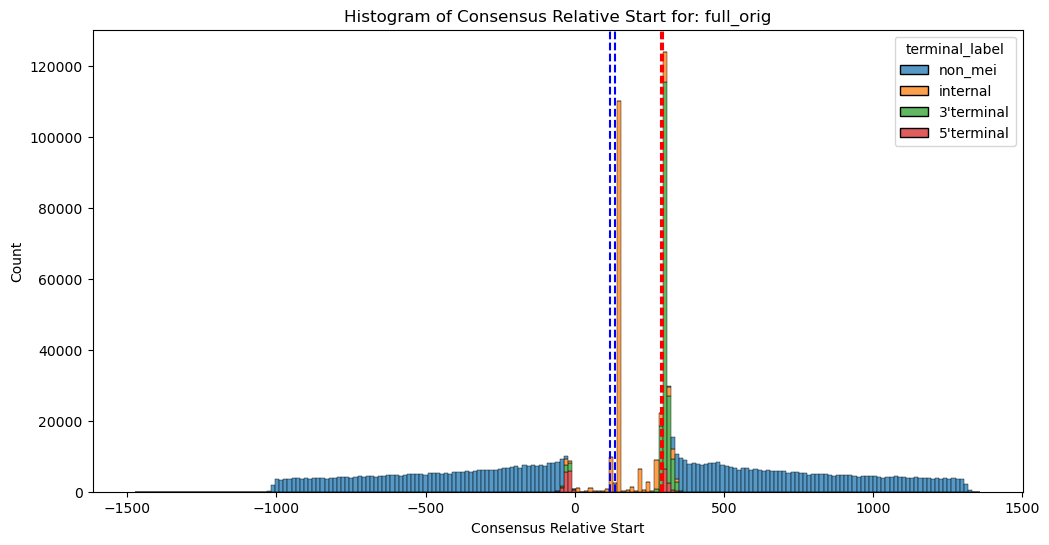

Mode consensus_relative_start for truncated_orig: 122.0


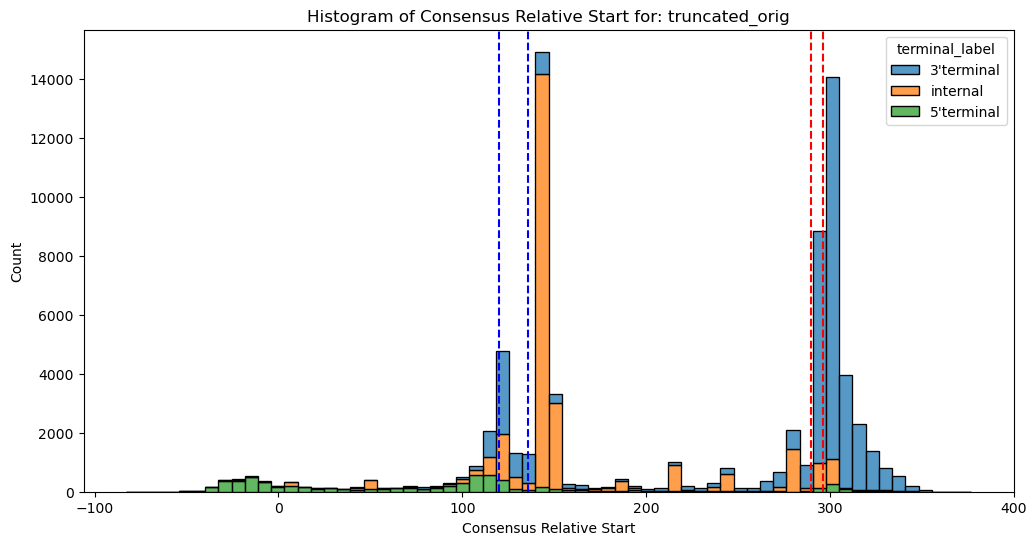

Mode consensus_relative_start for full_corrected: 122.0


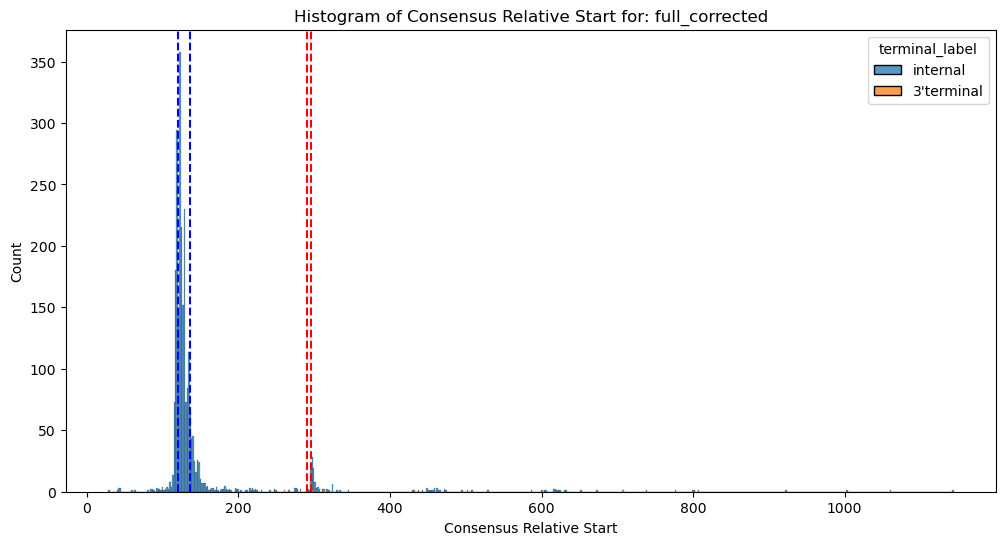

Mode consensus_relative_start for truncated_corrected: 118.0


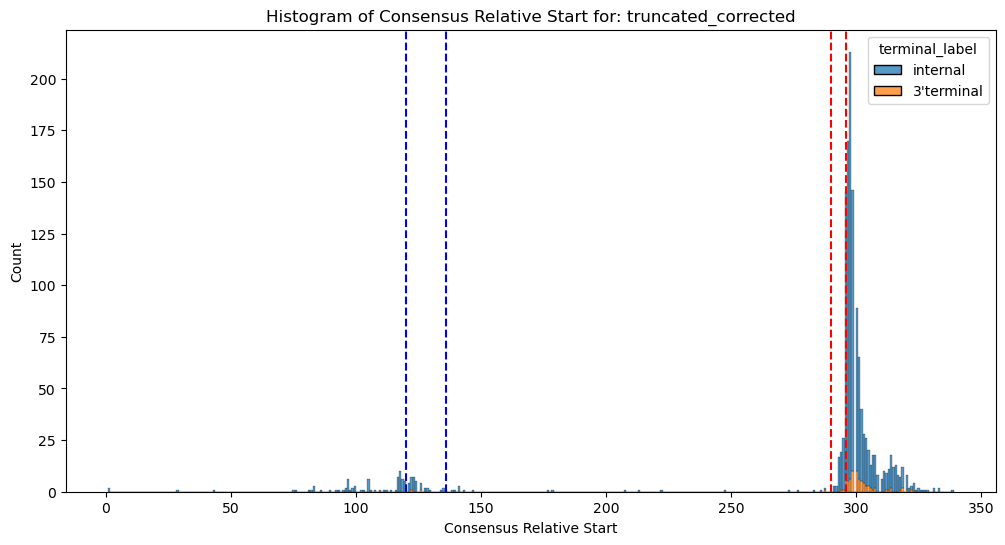

In [ ]:
# fill terminal_label with non_mei for non_mei in internal_external
full_orig_df.loc[full_orig_df["internal_external"] == "non_mei", "terminal_label"] = "non_mei"
# also do this for dist >25 or less than -25
full_orig_df.loc[full_orig_df["dist"] > 25, "terminal_label"] = "non_mei"
full_orig_df.loc[full_orig_df["dist"] < -25, "terminal_label"] = "non_mei"

# Combine and filter

In [8]:
truncated_orig_filtered = truncated_orig_labels[(truncated_orig_labels["internal_external"] == "internal")|((truncated_orig_labels.terminal_label == "3'terminal")&(truncated_orig_labels.consensus_relative_start >= 290))]
truncated_orig_filtered

,chrom,start,end,LocusID,start_mei_orig,end_mei_orig,mei_id,mei_subfamily,orientation,consensus_relative_start,...,internal_external,str_motif,TRID,terminal_label,STR_classification,disease_id,mei_family,start_mei,end_mei,simple_motif
1,chr1,129540.0,129549.0,197.0,129383,129675,AluSx.chr1:129383-129675,AluSx,-,165.0,...,internal,CAC,1-129540-129549-CAC,internal,internal_fully_overlapped,non_disease_associated,SINE_Alu,129383,129675,ACC
2,chr1,143168.0,143184.0,215.0,143165,143272,AluJb.chr1:143165-143272,AluJb,-,298.0,...,internal,TATTT,1-143168-143184-TATTT,3'terminal,internal_fully_overlapped,non_disease_associated,SINE_Alu,143165,143272,AAAAT
3,chr1,147074.0,147083.0,223.0,147060,147161,AluJb.chr1:147060-147161,AluJb,-,146.0,...,internal,CAC,1-147074-147083-CAC,internal,internal_fully_overlapped,NaN,SINE_Alu,147060,147161,ACC
5,chr1,155995.0,156014.0,242.0,155995,156114,AluJb.chr1:155995-156114,AluJb,-,298.0,...,external,TTTTA,1-155995-156014-TTTTA,3'terminal,external_downstream_overlap,NaN,SINE_Alu,155995,156114,AAAAT
6,chr1,159497.0,159506.0,248.0,159356,159579,AluSx1.chr1:159356-159579,AluSx1,+,147.0,...,internal,TGG,1-159497-159506-TGG,internal,internal_fully_overlapped,NaN,SINE_Alu,159356,159579,ACC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77442,chrY,26369991.0,26370000.0,4541384.0,26369878,26370158,AluJr.chrY:26369878-26370158,AluJr,+,147.0,...,internal,TGG,Y-26369991-26370000-TGG,internal,internal_fully_overlapped,NaN,SINE_Alu,26369878,26370158,ACC
77444,chrY,26482855.0,26482864.0,4541622.0,26482806,26483001,AluJo.chrY:26482806-26483001,AluJo,-,146.0,...,internal,CAC,Y-26482855-26482864-CAC,internal,internal_fully_overlapped,NaN,SINE_Alu,26482806,26483001,ACC
77445,chrY,26573674.0,26573689.0,4541784.0,26573703,26573948,AluJo.chrY:26573703-26573948,AluJo,-,327.0,...,external,TTCT,Y-26573674-26573689-TTCT,3'terminal,external_downstream_proximity,NaN,SINE_Alu,26573703,26573948,AAAG
77446,chrY,26534646.0,26534656.0,4541725.0,26534537,26534794,AluSg.chrY:26534537-26534794,AluSg,+,147.0,...,internal,TGG,Y-26534646-26534656-TGG,internal,internal_fully_overlapped,NaN,SINE_Alu,26534537,26534794,ACC


In [ ]:
combined = pd.concat([full_corrected_df.drop_duplicates(subset=["LocusID"], keep="first"), truncated_corrected_df.drop_duplicates(subset=["LocusID"], keep="first"), full_orig_df.drop_duplicates(subset=["LocusID"], keep="first"), truncated_orig_filtered.drop_duplicates(subset=["LocusID"], keep="first")], ignore_index=True)
combined.drop_duplicates(subset=["LocusID"], inplace=True)
print("Combined length with ambiguous 5' STRs: ", combined.shape[0])
combined = combined[~((combined.STR_classification == "external_different_meis") & (combined.terminal_label == "5'terminal"))]
combined

Combined length with ambiguous 5' STRs:  1145638


,chrom,start,end,LocusID,start_mei,end_mei,mei_id,mei_subfamily,orientation,consensus_relative_start,...,disease_id,mei_family,simple_motif,chrom_mei,dist,start_mei_final,end_mei_final,TRID,start_mei_orig,end_mei_orig
0,chr8,735310.0,735365.0,2083543.0,735178,735310,AluSc5.chr8:735178-735310,AluSc5,+,139.0,...,non_disease_associated,SINE_Alu,AAT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,chr20,737623.0,737660.0,4050606.0,737494,737624,AluSq2.chr20:737494-737624,AluSq2,+,133.0,...,non_disease_associated,SINE_Alu,AAT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,chr9,948902.0,948945.0,2300668.0,948779,948903,AluSx1.chr9:948779-948903,AluSx1,+,133.0,...,non_disease_associated,SINE_Alu,AAT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,chr19,1191065.0,1191093.0,3934403.0,1190941,1191057,AluSx1.chr19:1190941-1191057,AluSx1,+,133.0,...,non_disease_associated,SINE_Alu,AAAAT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,chr1,1653824.0,1653863.0,2476.0,1653702,1653825,AluSx.chr1:1653702-1653825,AluSx,+,126.0,...,non_disease_associated,SINE_Alu,AC,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1185683,chrY,26279995.0,26280009.0,4541262.0,26280013,26280121,AluSx3.chrY:26280013-26280121,AluSx3,-,317.0,...,NaN,SINE_Alu,AAC,NaN,NaN,26280013.0,26280121.0,Y-26279995-26280009-TTG,26280013.0,26280121.0
1185684,chrY,26373277.0,26373286.0,4541392.0,26373268,26373433,AluSx3.chrY:26373268-26373433,AluSx3,+,146.0,...,NaN,SINE_Alu,ACC,NaN,NaN,26373268.0,26373433.0,Y-26373277-26373286-GTG,26373268.0,26373433.0
1185686,chrY,26369991.0,26370000.0,4541384.0,26369878,26370158,AluJr.chrY:26369878-26370158,AluJr,+,147.0,...,NaN,SINE_Alu,ACC,NaN,NaN,26369878.0,26370158.0,Y-26369991-26370000-TGG,26369878.0,26370158.0
1185687,chrY,26482855.0,26482864.0,4541622.0,26482806,26483001,AluJo.chrY:26482806-26483001,AluJo,-,146.0,...,NaN,SINE_Alu,ACC,NaN,NaN,26482806.0,26483001.0,Y-26482855-26482864-CAC,26482806.0,26483001.0


There are 105222 poly(A) STRs in this set.
There are 14751 Alinker STRs in this set.


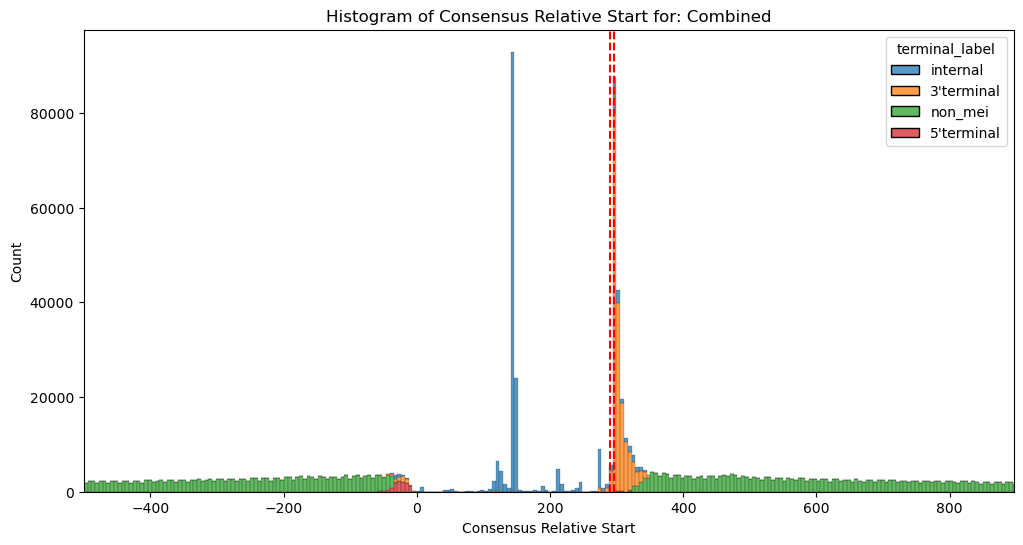

In [11]:
plt.figure(figsize=(12, 6))
sb.histplot(data=combined, x="consensus_relative_start", hue="terminal_label", multiple="stack", bins=500)
plt.title("Histogram of Consensus Relative Start for: {}".format("Combined"))
plt.xlabel("Consensus Relative Start")
plt.ylabel("Count")
# plot the polyA line at 296
plt.axvline(x=296, color="red", linestyle="--")
plt.axvline(x=290, color="red", linestyle="--")
plt.xlim(-500, 896)
# how many poly(A) strs are in this set? these are STRs thar start after 290 and before 301
print(f"There are {combined[(combined['consensus_relative_start'] > 290) & (combined['consensus_relative_start'] < 301)].shape[0]} poly(A) STRs in this set.")

# get the number of Alinker STRs there are in this set defined by 115 to 136
print(f"There are {combined[(combined['consensus_relative_start'] >= 115) & (combined['consensus_relative_start'] <= 136)].shape[0]} Alinker STRs in this set.")

In [12]:
all_labels = combined.merge(final_labels[["LocusID","mei_subfamily","mei","divergence"]], on="LocusID", how="left",suffixes=("","_final"))
all_labels = all_labels[all_labels.mei_subfamily_final.str.contains("Alu")]
all_labels["label"] = "Other"
# make label Alinker if consensus_relative_start is between 115 and 137
all_labels.loc[(all_labels["consensus_relative_start"] >= 115) & (all_labels["consensus_relative_start"] <= 137), "label"] = "Alinker"
all_labels.loc[all_labels["consensus_relative_start"] > 290, "label"] = "Poly(A)"
all_labels.label.value_counts()

label
Poly(A)    202581
Other      180282
Alinker     14902
Name: count, dtype: int64

# TODO this is not a cleaned up file -- if including in submission materials only include necessary columns

In [ ]:
# all_labels.to_csv("/nfs/boylelab_turbo/kvandeyn/MEI_STR/data/TR_catalog_HPRC/alu_lineage_data/alu_sets/combined_alu_strs_for_divergence_analysis_manuscript.tsv", sep="\t", index=False)
# also save the combined for reference later
combined.to_csv("combined_alu_context_manuscript.tsv", sep="\t", index=False)

# Figure 4B: Start Position Histogram

In [ ]:
plot_dir = "/home/kvandeyn/MEI_STR/scripts/notebooks/MEI_STR/manuscript_figures/figure_4_manuscript"

In [ ]:
combined = pd.read_csv("combined_alu_context_manuscript.tsv", sep="\t")
combined.mei_family.value_counts()

/tmp/ipykernel_2342904/1452791420.py:1: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  combined = pd.read_csv("/nfs/boylelab_turbo/kvandeyn/MEI_STR/data/TR_catalog_HPRC/alu_lineage_data/alu_sets/combined_alu_context_manuscript.tsv", sep="\t")


mei_family
non_mei           424408
SINE_Alu          406302
LINE_L1           145747
LINE_L2            44694
SINE_MIR           39292
LTR_ERVL-MaLR      29759
LTR_ERV1           17585
LTR_ERVL           15656
LINE_CR1            3165
LTR_ERVK            1086
LTR_Gypsy           1078
LINE_RTE-X           990
Retroposon_SVA       791
LTR_Gypsy?           510
LTR                  474
LTR?                 411
LINE_RTE-BovB        375
LTR_ERVL?            265
SINE_tRNA-RTE        166
LTR_ERV1?            107
SINE_5S-Deu-L2        93
SINE_tRNA             70
LINE_Dong-R4          26
LINE_Penelope         24
LINE_L1-Tx1           13
SINE_tRNA-Deu         13
.                     13
LINE_Jockey            2
Name: count, dtype: int64

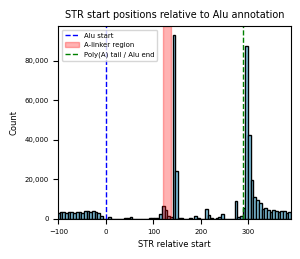

In [16]:
# make a histogram of the consensus_relative_start column with labels for where the Alu starts and ends as well as a highlight of the A linker region where the A linker region starts at 115 and ends at 137 and the poly(A) tail/ end of the Alu is at 290
import matplotlib.pyplot as plt
from pyparsing import line

# only plot the -200 to 200 after the poly(A) tail
# only plot the -200 to 200 after the poly(A) tail
# make the plot 3x3
plt.figure(figsize=(3,2.5))
ax = plt.gca()
ax.hist(combined['consensus_relative_start'], bins=500, color='skyblue', edgecolor='black')
ax.set_xlim(-100, 100 + 290)

# add an Alu start line at 0
ax.axvline(x=0, color='blue', linestyle='--', label='Alu start', linewidth=1)

# add a highlighted region for the A linker
ax.axvspan(120, 137, color='red', alpha=0.3, label='A-linker region')
ax.axvline(x=290, color='green', linestyle='--', label='Poly(A) tail / Alu end', linewidth=1)

ax.set_xlabel('STR relative start', fontsize=6)
ax.set_ylabel('Count', fontsize=6)
ax.set_title('STR start positions relative to Alu annotation', fontsize=7)

# make the y axis have commas
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:,.0f}'.format(x)))
ax.tick_params(axis='both', labelsize=5)

plt.legend(fontsize=5)

# save the figure to the plot directory
plt.savefig(f"{plot_dir}/figure4B_Alu_relative_position_histogram.pdf", dpi=300, bbox_inches='tight')


plt.show()


In [17]:
combined.loc[(combined["consensus_relative_start"] >= 115) & (combined["consensus_relative_start"] <= 137), "label"] = "Alinker"
combined.loc[combined["consensus_relative_start"] > 290, "label"] = "Poly(A)"

# print the proportion of Alu-STRs from Alinker and Poly(A) groups
total_alu = combined[combined["mei_family"] == "SINE_Alu"].shape[0]
alinker_count = combined[(combined["mei_family"] == "SINE_Alu") & (combined["label"] == "Alinker")].shape[0]
polya_count = combined[(combined["mei_family"] == "SINE_Alu") & (combined["label"] == "Poly(A)")].shape[0]
print(f"Alinker: {alinker_count/total_alu:.2%}, Poly(A): {polya_count/total_alu:.2%}")
# print how many Alu-STRs are included in the set
print(f"Total Alu-STRs included in the set: {total_alu}")
# how many non-MEI STRs are included with distance < 200bp
non_mei_str_count = combined[(combined["mei_family"] != "SINE_Alu") & (combined["dist"] < 200)].shape[0]
print(f"Total non-TE STRs with distance < 200bp: {non_mei_str_count}")

Alinker: 3.67%, Poly(A): 50.87%
Total Alu-STRs included in the set: 406302
Total non-TE STRs with distance < 200bp: 199204


# Load LPS data

In [ ]:
LPS = pd.read_csv("../feature_generation_scripts/LPS_metrics_with_annotations.tsv.gz", compression="gzip", sep="\t")
print(LPS.head())

   LocusID chrom  start    end       Mean     Stdev  unique_lps  \
0       15  chr1  14068  14081  12.000000  0.000000           1   
1       16  chr1  15810  15822   5.887500  1.894028           3   
2       17  chr1  16618  16632  11.944099  0.707093           2   
3       18  chr1  16715  16727   8.981366  0.235698           2   
4       19  chr1  19174  19184   9.000000  0.000000           1   

   disease_associated exclusion_type  str_period  ...              disease_id  \
0               False           keep         4.0  ...  non_disease_associated   
1               False           keep         3.0  ...  non_disease_associated   
2               False           keep         3.0  ...  non_disease_associated   
3               False           keep         3.0  ...  non_disease_associated   
4               False           keep         3.0  ...  non_disease_associated   

  num_total_lps_motifs    mei  mei_family  mei_subfamily start_mei end_mei  \
0                    1  False   

In [19]:
# merge combined on LPS to get Mean and Stdev
combined = combined.merge(LPS[["LocusID", "Mean", "Stdev","disease_associated","unique_lps"]], on="LocusID", how="left")
# get unique_lps from alu_features
combined.dropna(subset=["unique_lps"], inplace=True)

In [20]:
# how many Alu-STRs are variable
variable_alu_count = combined[(combined["mei_family"] == "SINE_Alu") & (combined["unique_lps"] > 1)].shape[0]
# how many total Alu-STRs are there
total_alu = combined[combined["mei_family"] == "SINE_Alu"].shape[0]
print(f"Total Alu-STRs: {total_alu}")
print(f"Total variable Alu-STRs: {variable_alu_count}")
# print the rate
print(f"Rate of variable Alu-STRs: {variable_alu_count/total_alu:.2%}")
# how many non-MEI STRs are included with distance < 200bp
non_mei_str_count = combined[(combined["mei_family"] == "non_mei") & ((combined["dist"] < 200)| (combined["dist"] > 200+296))].shape[0]
print(f"Total non-TE STRs with distance < 200bp: {non_mei_str_count}")
# get variable non-TE STRs with distance < 200bp
variable_non_mei_str_count = combined[(combined['mei_family'] == "non_mei") & ((combined["dist"] < 200)| (combined["dist"] > 200+296))& (combined["unique_lps"] > 1)].shape[0]
print(f"Total variable non-TE STRs with distance < 200bp: {variable_non_mei_str_count}")
print(f"Rate of variable non-TE STRs with distance < 200bp: {variable_non_mei_str_count/non_mei_str_count:.2%}")

Total Alu-STRs: 398992
Total variable Alu-STRs: 94538
Rate of variable Alu-STRs: 23.69%
Total non-TE STRs with distance < 200bp: 280851
Total variable non-TE STRs with distance < 200bp: 48854
Rate of variable non-TE STRs with distance < 200bp: 17.39%


# Figure 4C: A linker vs Poly(A) heatmap
TODO the combined dataframe only contains the non-MEI regions within 1kb of a full length Alu so the LPS distribution may be slightly different than the previous figure, need to decide if that is okay just see how different

In [21]:
# build heatmap comparing non-MEI STRs to A-linker and Poly(A) STRs (labels derived from consensus_relative_start)
heatmap_df = combined[
    (combined["mei_family"].isin(["SINE_Alu", "non_mei"])) &
    (combined.simple_motif.str.len() == combined.str_motif.str.len()) &
    (combined.Stdev > 0) &
    ((combined.label == "Poly(A)") |(combined.label == "Alinker")| (combined.terminal_label == "non_mei"))
].copy()

# plot_label: non-MEI for non_mei family, otherwise use the label column (Alinker / Poly(A) / Other)
heatmap_df["plot_label"] = np.where(
    heatmap_df["mei_family"] == "non_mei",
    "non-TE",
    heatmap_df["label"]
)

# only keep rows labeled non-TE, Alinker, or Poly(A)
heatmap_df = heatmap_df[heatmap_df["plot_label"].isin(["non-TE", "Alinker", "Poly(A)"])]

# if a given motif per group has less than 5 rows, set Mean to nan so it's excluded from normalization/display
family_cols = ["non-TE", "Alinker", "Poly(A)"]
group_counts = (
    heatmap_df.groupby(["simple_motif", "plot_label"])
    .size()
    .unstack(fill_value=0)
)
for family in family_cols:
    if family in group_counts.columns:
        heatmap_df.loc[
            (heatmap_df["plot_label"] == family) & (group_counts[family] < 5),
            "Mean",
        ] = np.nan

mean_heatmap = (
    heatmap_df.groupby(["simple_motif", "plot_label"], as_index=False)["Mean"]
    .mean()
    .pivot(index="simple_motif", columns="plot_label", values="Mean")
)

# require that at least 2 of the 3 groups have non-na values for a motif to be included
mean_heatmap = mean_heatmap[mean_heatmap[family_cols].notna().sum(axis=1) >= 2]

In [22]:
mean_heatmap

plot_label,Alinker,Poly(A),non-TE
simple_motif,,,
AAAAAC,21.530604,21.221868,19.565822
AAAAAG,16.371381,18.514611,17.735979
AAAAAT,19.115235,19.488797,18.181046
AAAAC,21.320016,21.849595,19.163574
AAAACC,17.755102,21.087978,19.138258
...,...,...,...
CCCCCG,NaN,17.555556,16.754992
CCCCG,NaN,15.615486,16.678300
CCCG,NaN,11.958811,12.377630


In [23]:
from scipy.stats import mannwhitneyu
# using the heatmap_df test for significant difference between non-mei and Alu for all AT base composition motifs
AT_motifs= ["AT","AAT","AAAT","AAAAT","AAAAAT"]
polya_label = "Poly(A)"
alinker_label = 'Alinker'

for motif in AT_motifs:
    x = heatmap_df[(heatmap_df["plot_label"] == polya_label) &(heatmap_df.simple_motif == motif)]["Mean"].astype(float)
    y = heatmap_df[(heatmap_df["plot_label"] == alinker_label) &(heatmap_df.simple_motif == motif)]["Mean"].astype(float)
    # compare non-MEI and Alu for this motif with a Mann-Whitney U test
    u_stat, p_val = mannwhitneyu(x, y, alternative='two-sided')
    polya_mean = x.mean()
    alinker_mean = y.mean()
    print(f"{motif}: {polya_mean.round(2)} vs {alinker_mean.round(2)}, p-value: {p_val}")


AT: 14.35 vs 15.81, p-value: 0.0010163915570523387
AAT: 21.03 vs 20.44, p-value: 0.08418420412652813
AAAT: 23.85 vs 24.61, p-value: 0.1393794593236302
AAAAT: 24.29 vs 23.93, p-value: 0.5756657175070439
AAAAAT: 19.49 vs 19.12, p-value: 0.40959295260435624


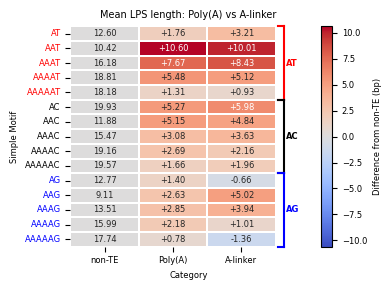

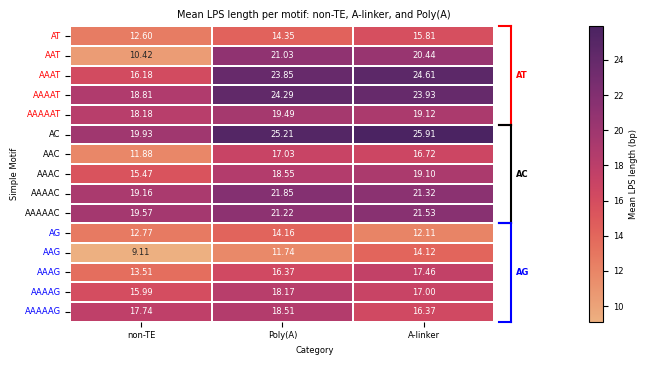

In [30]:
basecomp_order = ["AT", "AC", "AG", "CG"]

title_size =7
label_size = 6
ticks_sizes = 5

# groups from the MEI-family plot
group_cols = [c for c in ["non-TE", "Poly(A)", "Alinker"] if c in mean_heatmap.columns]
ref_col = "non-TE"
category_order=["non-TE","Poly(A)","Alinker"]

# update the label for Alinker to A-linker
category_order = ["non-TE","Poly(A)","A-linker"]
group_cols = [c if c != "Alinker" else "A-linker" for c in group_cols]
mean_heatmap = mean_heatmap.rename(columns={"Alinker": "A-linker"})

required_cols = [c for c in category_order if c in mean_heatmap.columns]
if required_cols != category_order:
    raise ValueError(
        f"mean_heatmap must contain columns: {category_order}. "
        f"Found: {list(mean_heatmap.columns)}"
    )

def get_base_composition(motif):
    return "".join(sorted(set(motif)))

def format_annotation(row_idx, col_name, raw_heatmap, diff_heatmap):
    if col_name == ref_col:
        return f"{raw_heatmap.iloc[row_idx][col_name]:.2f}"

    value = diff_heatmap.iloc[row_idx][col_name]
    if pd.isna(value):
        return ""

    sign = "+" if value >= 0 else ""
    return f"{sign}{value:.2f}"

# Select and order motifs
plot_norm_heatmap = mean_heatmap[category_order].copy()

plot_norm_heatmap = plot_norm_heatmap.loc[
    [
        motif for motif in plot_norm_heatmap.index
        if isinstance(motif, str)
        and len(set(motif)) == 2
        and motif.count("A") == len(motif) - 1
    ]
]

sorted_motifs = []
for basecomp in basecomp_order:
    motifs = [
        motif for motif in plot_norm_heatmap.index
        if get_base_composition(motif) == basecomp
    ]
    sorted_motifs.extend(sorted(motifs, key=len))

raw_heatmap = plot_norm_heatmap.loc[sorted_motifs].copy()
diff_heatmap = raw_heatmap.sub(raw_heatmap[ref_col], axis=0)

abs_max = np.nanmax(np.abs(diff_heatmap.to_numpy()))
if abs_max == 0:
    abs_max = 1

annot_matrix = pd.DataFrame(
    [
        [
            format_annotation(i, col, raw_heatmap, diff_heatmap)
            for col in diff_heatmap.columns
        ]
        for i in range(len(diff_heatmap))
    ],
    index=diff_heatmap.index,
    columns=diff_heatmap.columns,
)

basecomp_colors = {
    "AT": "red",
    "AC": "black",
    "AG": "blue",
    "CG": "green",
}

def add_basecomp_brackets(ax, heatmap):
    n_cols = heatmap.shape[1]
    basecomps = np.array([
        get_base_composition(motif)
        for motif in heatmap.index
    ])

    current = None
    start = 0

    def draw_bracket(basecomp, y0, y1):
        x0, x1 = n_cols + 0.03, n_cols + 0.12
        color = basecomp_colors.get(basecomp, "black")

        ax.plot([x0, x1], [y0, y0], color=color, lw=1.5, clip_on=False)
        ax.plot([x0, x1], [y1, y1], color=color, lw=1.5, clip_on=False)
        ax.plot([x1, x1], [y0, y1], color=color, lw=1.5, clip_on=False)
        ax.text(
            x1 + 0.03,
            (y0 + y1) / 2,
            basecomp,
            va="center",
            ha="left",
            fontsize=label_size,
            color=color,
            fontweight="bold",
            clip_on=False,
        )

    for i, basecomp in enumerate(basecomps):
        if basecomp != current:
            if current is not None:
                draw_bracket(current, start, i)
            current = basecomp
            start = i

    if current is not None:
        draw_bracket(current, start, len(basecomps))

    for label in ax.get_yticklabels():
        basecomp = get_base_composition(label.get_text())
        label.set_color(basecomp_colors.get(basecomp, "black"))
        label.set_fontsize(label_size)

    ax.set_xlim(0, n_cols + 0.45)


# Difference heatmap
fig, ax = plt.subplots(figsize=(12 / 3, 3))

sb.heatmap(
    diff_heatmap,
    cmap="coolwarm",
    center=0,
    vmin=-abs_max,
    vmax=abs_max,
    annot=annot_matrix,
    fmt="",
    annot_kws={"fontsize": label_size},
    linewidths=0.3,
    cbar=False,
    ax=ax,
)

cbar = fig.colorbar(
    ax.collections[0],
    ax=ax,
    label="Difference from non-TE (bp)",
)
cbar.ax.yaxis.label.set_size(label_size)
cbar.ax.tick_params(labelsize=label_size)

add_basecomp_brackets(ax, diff_heatmap)

ax.tick_params(axis="x", labelsize=label_size)
ax.set_title(
    "Mean LPS length: Poly(A) vs A-linker",
    fontsize=title_size,
)
ax.set_xlabel("Category", fontsize=label_size)
ax.set_ylabel("Simple Motif", fontsize=label_size)

plt.tight_layout()
plt.savefig(
    plot_dir + "/figure4C_LPS_heatmap_Alinker_polyA.pdf",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


# Raw-value heatmap
fig, ax = plt.subplots(figsize=(7, min(4, 0.25 * len(raw_heatmap))))

sb.heatmap(
    raw_heatmap,
    cmap="flare",
    annot=raw_heatmap,
    fmt=".2f",
    annot_kws={"fontsize": label_size},
    linewidths=0.3,
    cbar=False,
    ax=ax,
)

cbar = fig.colorbar(
    ax.collections[0],
    ax=ax,
    label="Mean LPS length (bp)",
)
cbar.ax.yaxis.label.set_size(label_size)
cbar.ax.tick_params(labelsize=label_size)

add_basecomp_brackets(ax, raw_heatmap)

ax.tick_params(axis="both", labelsize=label_size)
ax.set_title(
    "Mean LPS length per motif: non-TE, A-linker, and Poly(A)",
    fontsize=title_size,
)
ax.set_xlabel("Category", fontsize=label_size)
ax.set_ylabel("Simple Motif", fontsize=label_size)

plt.tight_layout()
plt.savefig(
    plot_dir + "/supplemental_LPS_heatmap_raw_Alinker_polyA.pdf",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


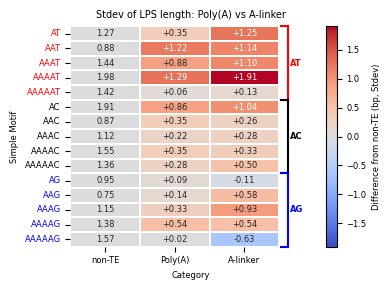

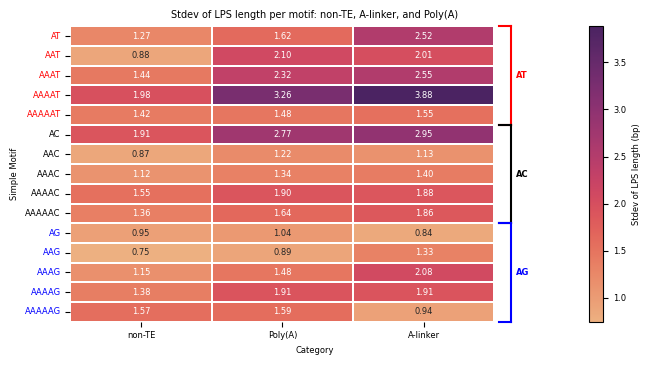

In [33]:
basecomp_order = ["AT", "AC", "AG", "CG"]

title_size = 7
label_size = 6
ticks_sizes = 5

# Build a Stdev heatmap analogous to mean_heatmap, but using the Stdev column
stdev_heatmap = heatmap_df.pivot_table(
    index="simple_motif",
    columns="plot_label",
    values="Stdev",
    aggfunc="mean",
)

# groups from the MEI-family plot
stdev_heatmap = stdev_heatmap.rename(columns={"Alinker": "A-linker"})
group_cols = [c for c in ["non-TE", "Poly(A)", "A-linker"] if c in stdev_heatmap.columns]
ref_col = "non-TE"
category_order = ["non-TE", "Poly(A)", "A-linker"]
required_cols = [c for c in category_order if c in stdev_heatmap.columns]
# Update any references to "Alinker" to "A-linker" in the stdev_heatmap columns

if required_cols != category_order:
    raise ValueError(
        f"stdev_heatmap must contain columns: {category_order}. "
        f"Found: {list(stdev_heatmap.columns)}"
    )

def get_base_composition(motif):
    return "".join(sorted(set(motif)))

def format_annotation(row_idx, col_name, raw_heatmap, diff_heatmap):
    if col_name == ref_col:
        return f"{raw_heatmap.iloc[row_idx][col_name]:.2f}"

    value = diff_heatmap.iloc[row_idx][col_name]
    if pd.isna(value):
        return ""

    sign = "+" if value >= 0 else ""
    return f"{sign}{value:.2f}"

# Select and order motifs
plot_norm_heatmap = stdev_heatmap[category_order].copy()

plot_norm_heatmap = plot_norm_heatmap.loc[
    [
        motif for motif in plot_norm_heatmap.index
        if isinstance(motif, str)
        and len(set(motif)) == 2
        and motif.count("A") == len(motif) - 1
    ]
]

sorted_motifs = []
for basecomp in basecomp_order:
    motifs = [
        motif for motif in plot_norm_heatmap.index
        if get_base_composition(motif) == basecomp
    ]
    sorted_motifs.extend(sorted(motifs, key=len))

raw_heatmap = plot_norm_heatmap.loc[sorted_motifs].copy()
diff_heatmap = raw_heatmap.sub(raw_heatmap[ref_col], axis=0)

abs_max = np.nanmax(np.abs(diff_heatmap.to_numpy()))
if abs_max == 0:
    abs_max = 1

annot_matrix = pd.DataFrame(
    [
        [
            format_annotation(i, col, raw_heatmap, diff_heatmap)
            for col in diff_heatmap.columns
        ]
        for i in range(len(diff_heatmap))
    ],
    index=diff_heatmap.index,
    columns=diff_heatmap.columns,
)

basecomp_colors = {
    "AT": "red",
    "AC": "black",
    "AG": "blue",
    "CG": "green",
}

def add_basecomp_brackets(ax, heatmap):
    n_cols = heatmap.shape[1]
    basecomps = np.array([
        get_base_composition(motif)
        for motif in heatmap.index
    ])

    current = None
    start = 0

    def draw_bracket(basecomp, y0, y1):
        x0, x1 = n_cols + 0.03, n_cols + 0.12
        color = basecomp_colors.get(basecomp, "black")

        ax.plot([x0, x1], [y0, y0], color=color, lw=1.5, clip_on=False)
        ax.plot([x0, x1], [y1, y1], color=color, lw=1.5, clip_on=False)
        ax.plot([x1, x1], [y0, y1], color=color, lw=1.5, clip_on=False)
        ax.text(
            x1 + 0.03,
            (y0 + y1) / 2,
            basecomp,
            va="center",
            ha="left",
            fontsize=label_size,
            color=color,
            fontweight="bold",
            clip_on=False,
        )

    for i, basecomp in enumerate(basecomps):
        if basecomp != current:
            if current is not None:
                draw_bracket(current, start, i)
            current = basecomp
            start = i

    if current is not None:
        draw_bracket(current, start, len(basecomps))

    for label in ax.get_yticklabels():
        basecomp = get_base_composition(label.get_text())
        label.set_color(basecomp_colors.get(basecomp, "black"))
        label.set_fontsize(label_size)

    ax.set_xlim(0, n_cols + 0.45)


# Difference heatmap (Stdev)
fig, ax = plt.subplots(figsize=(12 / 3, 3))

sb.heatmap(
    diff_heatmap,
    cmap="coolwarm",
    center=0,
    vmin=-abs_max,
    vmax=abs_max,
    annot=annot_matrix,
    fmt="",
    annot_kws={"fontsize": label_size},
    linewidths=0.3,
    cbar=False,
    ax=ax,
)

cbar = fig.colorbar(
    ax.collections[0],
    ax=ax,
    label="Difference from non-TE (bp, Stdev)",
)
cbar.ax.yaxis.label.set_size(label_size)
cbar.ax.tick_params(labelsize=label_size)

add_basecomp_brackets(ax, diff_heatmap)

ax.tick_params(axis="x", labelsize=label_size)
ax.set_title(
    "Stdev of LPS length: Poly(A) vs A-linker",
    fontsize=title_size,
)
ax.set_xlabel("Category", fontsize=label_size)
ax.set_ylabel("Simple Motif", fontsize=label_size)

plt.tight_layout()
plt.savefig(
    plot_dir + "/supplemental_LPS_stdev_heatmap_diff_Alinker_polyA.pdf",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


# Raw-value heatmap (Stdev)
fig, ax = plt.subplots(figsize=(7, min(4, 0.25 * len(raw_heatmap))))

sb.heatmap(
    raw_heatmap,
    cmap="flare",
    annot=raw_heatmap,
    fmt=".2f",
    annot_kws={"fontsize": label_size},
    linewidths=0.3,
    cbar=False,
    ax=ax,
)

cbar = fig.colorbar(
    ax.collections[0],
    ax=ax,
    label="Stdev of LPS length (bp)",
)
cbar.ax.yaxis.label.set_size(label_size)
cbar.ax.tick_params(labelsize=label_size)

add_basecomp_brackets(ax, raw_heatmap)

ax.tick_params(axis="both", labelsize=label_size)
ax.set_title(
    "Stdev of LPS length per motif: non-TE, A-linker, and Poly(A)",
    fontsize=title_size,
)
ax.set_xlabel("Category", fontsize=label_size)
ax.set_ylabel("Simple Motif", fontsize=label_size)

plt.tight_layout()
plt.savefig(
    plot_dir + "/supplemental_LPS_stdev_heatmap_raw_Alinker_polyA.pdf",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


# Figure 4D: LPS Metric Scatter Plots

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def plot_lps_vs_consensus_relative_start_combined(
    df,
    highlight_disease_regions=False,
    plot_rolling_mean=True,
    rolling_window=100,
    rolling_min_periods=10,
    marker_size=7,
    color_by='str_period',
    color_labels=None,
    colors=None,
    disease_color_map=None,
    output_file=None
):
    title_size = 7
    label_size = 6
    tick_sizes = 5
    # Define plotting bounds
    x_min, x_max = -200, 496
    plot_df = df[(df["consensus_relative_start"] >= x_min) & (df["consensus_relative_start"] <= x_max)]

    # Base palette
    safe_palette = ['#7f7f7f', '#ff7f0e', '#2ca02c', '#d62728', 
                    '#9467bd', '#8c564b', '#e377c2', '#1f77b4', '#17becf']

    # Base group color mapping
    unique_vals = sorted(plot_df[color_by].dropna().unique())
    n_colors = len(unique_vals)
    colors = safe_palette[:n_colors]
    cmap = mcolors.ListedColormap(colors)
    norm = mcolors.BoundaryNorm(boundaries=np.arange(n_colors+1)-0.5, ncolors=n_colors)

    # Legend labels for base groups
    if color_labels is None:
        color_labels = []
        for v in unique_vals:
            if v == "SINE_Alu":
                color_labels.append("Alu-STRs")
            elif v == "non_mei":
                color_labels.append("non-TE STRs")
            else:
                color_labels.append(str(v))

    handles = [plt.Line2D([0], [0], marker='o', color='w', label=label,
                          markerfacecolor=colors[i % len(colors)], markersize=7)
               for i, label in enumerate(color_labels)]

    # Disease-associated subset
    disease_df = plot_df[plot_df['disease_associated'] == True] if 'disease_associated' in plot_df.columns else plot_df.iloc[[]]
    disease_ids = disease_df['disease_id'].unique() if 'disease_id' in plot_df.columns and len(disease_df) > 0 else []
    print(disease_ids)

    # Disease color map
    if disease_color_map is None and len(disease_ids) > 0:
        forbidden_colors = set(safe_palette[:2])

        # Generate unique colors while excluding grey and orange.
        candidate_colors = [
            mcolors.to_hex(plt.cm.tab20(i / 19))
            for i in range(20)
        ]
        candidate_colors = [
            color for color in candidate_colors
            if color not in forbidden_colors
        ]

        # Extend the palette if there are more disease IDs than candidates.
        if len(disease_ids) > len(candidate_colors):
            candidate_colors.extend(
                mcolors.to_hex(plt.cm.hsv(i / len(disease_ids)))
                for i in range(len(disease_ids))
            )

        disease_color_map = {
            disease_id: candidate_colors[i]
            for i, disease_id in enumerate(disease_ids)
        }

    # Plot loop
    fig, ax = plt.subplots(3, 1, figsize=(3, 5))

    for i, (metric, ylabel, title) in enumerate(zip(
        ["Mean", "Stdev", "unique_lps"],
        ["Mean LPS", "Stdev LPS", "Unique LPS"],
        ["Mean LPS length",
         "Stdev LPS length",
         "Unique LPS lengths"]
    )):
        x = plot_df["consensus_relative_start"]
        y = plot_df[metric]
        c = plot_df[color_by].apply(lambda v: unique_vals.index(v) if v in unique_vals else np.nan)

        # Base scatter
        alpha_val = 0.5 if not highlight_disease_regions else 0.3
        ax[i].scatter(x, y, c=c, cmap=cmap, norm=norm, alpha=alpha_val, s=marker_size, label=None,rasterized=True)

        # Rolling mean
        if plot_rolling_mean:
            rolling_val = plot_df.sort_values("consensus_relative_start")[metric].rolling(
                window=rolling_window, min_periods=rolling_min_periods, center=True).mean()
            ax[i].plot(plot_df.sort_values("consensus_relative_start")["consensus_relative_start"],
                    rolling_val, color='black', linewidth=2)
        x = plot_df["consensus_relative_start"]
        y = plot_df[metric]
        c = plot_df[color_by].apply(lambda v: unique_vals.index(v) if v in unique_vals else np.nan)

        # Base scatter
        alpha_val = 0.5 if not highlight_disease_regions else 0.3
        ax[i].scatter(x, y, c=c, cmap=cmap, norm=norm, alpha=alpha_val, s=marker_size, label=None)

        # Rolling mean
        if plot_rolling_mean:
            rolling_val = plot_df.sort_values("consensus_relative_start")[metric].rolling(
                window=rolling_window, min_periods=rolling_min_periods, center=True).mean()
            ax[i].plot(plot_df.sort_values("consensus_relative_start")["consensus_relative_start"],
                    rolling_val, color='black', linewidth=2)

        # Reference lines
        ax[i].axvline(x=0, color='blue', linestyle='--', alpha=0.25, label='Alu start position')
        ax[i].axvline(x=296, color='green', linestyle='--', alpha=0.25, label='Poly(A) start position')

        # Shaded A-Linker region
        alinker_start, alinker_end = 120, 136
        if alinker_end >= x_min and alinker_start <= x_max:
            ax[i].axvspan(max(alinker_start, x_min), min(alinker_end, x_max),
                       color='red', alpha=0.2, label='A-linker region')

        # Disease points
        if highlight_disease_regions and len(disease_ids) > 0:
            for disease_id in disease_ids:
                d_mask = (plot_df['disease_id'] == disease_id)
                ax[i].scatter(x[d_mask], y[d_mask],
                           color=disease_color_map[disease_id],
                           s=marker_size*5,
                           edgecolor='black',
                           linewidth=0.6,
                           zorder=5,
                           label=str(disease_id),rasterized=True)

        # Axis formatting
        ax[i].set_xlim(x_min, x_max)
        ax[i].set_title("", fontsize=title_size) # remove titles since the axes are labled
        ax[i].set_xlabel('STR relative start position', fontsize=label_size)
        ax[i].set_ylabel(ylabel, fontsize=label_size)
        ax[i].tick_params(axis='both', labelsize=tick_sizes)
        ax[i].grid(axis='y', alpha=0.75)

        # Combine legends: base groups + diseases
        all_handles, all_labels = ax[i].get_legend_handles_labels()
        handles = [plt.Line2D([0], [0], marker='o', color='w', label=label,
                          markerfacecolor=colors[i % len(colors)], markersize=7)
               for i, label in enumerate(color_labels)]
        ax[i].legend(handles + all_handles, color_labels + all_labels,
                  title=None, fontsize=label_size, frameon=True, ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.15))
        # remove the legend to avoid clutter
        ax[i].legend().set_visible(False)
        # remove the x label for the first two plots

        # save this plot to output if output not none
    ax[0].set_xlabel("")
    ax[1].set_xlabel("")
    # don't show the x ticks
    ax[0].set_xticks([])
    ax[1].set_xticks([])

    # set a single legend for all three plots
    all_handles, all_labels = ax[0].get_legend_handles_labels()
    # map the True and False labels to Alu-STR and non-MEI STRs
    fig.legend(handles + all_handles, 
               [label if label not in ["True", "False"] else 'Alu-STR' if label == "True" else 'non-TE STR' for label in color_labels + all_labels],
               title=None, fontsize=label_size, frameon=True, ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.005))
    fig.suptitle("LPS metrics by STR relative start", fontsize=title_size)
    plt.tight_layout()
    # plt.savefig(output_file +"_combined_plot.pdf", bbox_inches='tight', dpi=300)


    if output_file is not None:
        # plt.savefig(output_file +"_combined_plot.pdf", bbox_inches='tight', dpi=600)
        plt.savefig(output_file + "_combined_plot.tiff", bbox_inches='tight', dpi=600, 
            format='tiff', pil_kwargs={"compression": "tiff_lzw"})
        plt.show()


In [27]:
combined["mei"] = combined.mei_family != "non_mei"
combined["dist"] = combined[ "dist"].replace({np.nan: 0}).fillna(0)
combined.loc[combined.disease_associated][["disease_id","dist"]]

,disease_id,dist
555,SCA37,0.0
215604,FRA12A,526.0
310580,SCA3,275.0
317858,ALS,583.0
368132,FAME6,10.0
383110,SCA31,3.0
483106,PSACH.MED,716.0
540854,FAME2,1.0
592830,SCA36,881.0
631296,EPM1,501.0


['SCA37' 'FAME6' 'SCA31' 'FAME2' 'DM2' 'FAME4' 'CANVAS' 'FAME3' 'FAME1'
 'FA' 'SCA10']


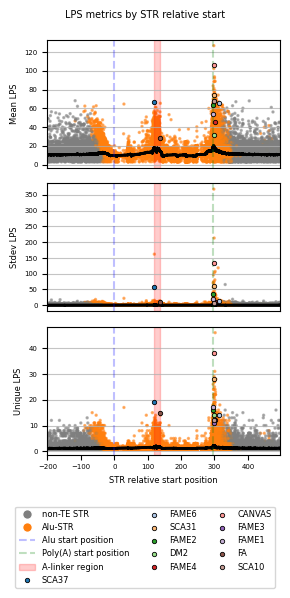

In [35]:
combined["period"] = combined["str_motif"].str.len()
# only include rows with period > 2
filtered_combined = combined[combined["period"] > 2]

plot_lps_vs_consensus_relative_start_combined(
    filtered_combined[((filtered_combined["dist"] <= 25) & (filtered_combined["mei_family"] == "SINE_Alu")) |
                      ((filtered_combined["dist"] > 0) & (filtered_combined["mei_family"] == "non_mei"))],
    highlight_disease_regions=True,
    plot_rolling_mean=True,
    rolling_window=500,
    rolling_min_periods=10,
    marker_size=2,
    color_by='mei',
    output_file=plot_dir + "/figure4D_Alu_relative_position")

In [129]:
# how many Alu STRs were included
print("Alu-STRs (all): ",filtered_combined[(filtered_combined["dist"] <= 25) & (filtered_combined["mei_family"] == "SINE_Alu")].shape[0])
print("Alu-STRs (variable): ",filtered_combined[(filtered_combined["dist"] <= 25) & (filtered_combined["mei_family"] == "SINE_Alu") & (filtered_combined["Stdev"] > 0)].shape[0])

# how many non-MEI STRs were included
print("non-MEI STRs (all): ",filtered_combined[(filtered_combined["dist"] > 0) & (filtered_combined["mei_family"] == "non_mei")].shape[0])
print("non-MEI STRs (variable): ",filtered_combined[(filtered_combined["dist"] > 0) & (filtered_combined["mei_family"] == "non_mei") & (filtered_combined["Stdev"] > 0)].shape[0])

Alu-STRs (all):  316927
Alu-STRs (variable):  71658
non-MEI STRs (all):  287022
non-MEI STRs (variable):  35898


## Exponential distribution fitting

R-squared: 0.90
P-values: const                       5.411698e-47
consensus_relative_start    1.722432e-21
dtype: float64
Intercept: 17.04
Slope: -0.16
R-squared: 0.94
P-values: const                       2.322239e-65
consensus_relative_start    6.609474e-25
dtype: float64
Intercept: 2.84
Slope: -0.01


/tmp/ipykernel_2342904/128301873.py:52: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data["log_Mean"] = np.log(filtered_data["Mean"])


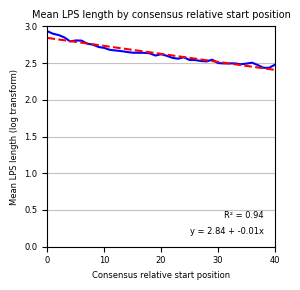

In [36]:
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
mean_lps_by_position = filtered_combined[(((filtered_combined["dist"] <= 25) & (filtered_combined["mei_family"] == "SINE_Alu")) |
                      ((filtered_combined["dist"] > 0) & (filtered_combined["mei_family"] == "non_mei")))].groupby("consensus_relative_start")["Mean"].mean().reset_index()
mean_lps_by_position["consensus_relative_start"] = mean_lps_by_position["consensus_relative_start"] - 296
filtered_data = mean_lps_by_position[mean_lps_by_position["consensus_relative_start"].between(0, 40)]

# non-log transform
X = filtered_data["consensus_relative_start"]
y = filtered_data["Mean"]
# Add a constant to X for the intercept
X = sm.add_constant(X)
# Fit the regression model
model = sm.OLS(y, X).fit()
# Get R-squared and p-values
r2 = model.rsquared
p_values = model.pvalues
# Print R-squared and p-values
print(f"R-squared: {r2:.2f}")
print(f"P-values: {p_values}")
print(f"Intercept: {model.params['const']:.2f}")
print(f"Slope: {model.params['consensus_relative_start']:.2f}")



X = filtered_data["consensus_relative_start"]
y = np.log(filtered_data["Mean"])

# Add a constant to X for the intercept
X = sm.add_constant(X)

# Fit the regression model
model = sm.OLS(y, X).fit()

# Get R-squared and p-values
r2 = model.rsquared
p_values = model.pvalues

# Print R-squared and p-values
print(f"R-squared: {r2:.2f}")
print(f"P-values: {p_values}")
# print the model coefficients
print(f"Intercept: {model.params['const']:.2f}")
print(f"Slope: {model.params['consensus_relative_start']:.2f}")

# Plot the regression line
y_pred = model.predict(X)

plt.figure(figsize=(3, 3))
filtered_data["log_Mean"] = np.log(filtered_data["Mean"])
sb.lineplot(data=filtered_data, x="consensus_relative_start", y="log_Mean", color="blue")
plt.title("Mean LPS length by consensus relative start position", fontsize=7)
plt.xlabel("Consensus relative start position", fontsize=6)
plt.ylabel("Mean LPS length (log transform)", fontsize=6)
plt.xticks(fontsize=6)
plt.yticks(fontsize=6)
plt.xlim(0,40)
plt.ylim(0, 3)
plt.grid(axis='y', alpha=0.75)
# add the regression line equation to the plot
plt.text(
    0.95, 0.05,
    f"y = {model.params['const']:.2f} + "
    f"{model.params['consensus_relative_start']:.2f}x",
    transform=plt.gca().transAxes,
    fontsize=6,
    horizontalalignment="right",
    verticalalignment="bottom",
)
plt.tight_layout()
plt.plot(
    filtered_data["consensus_relative_start"],
    y_pred,
    color="red",
    linestyle="--",
    label="Linear Regression",
)

plt.text(
    0.95,
    0.12,
    f"R² = {r2:.2f}",
    transform=plt.gca().transAxes,
    fontsize=6,
    ha="right",
    va="bottom",
)

# save as a supplemental figure
plt.savefig(plot_dir + "/supplemental_figure4_exponential_regression.pdf", dpi=300,bbox_inches='tight')


In [141]:
filtered_combined[(((filtered_combined["dist"] <= 25) & (filtered_combined["mei_family"] == "SINE_Alu")) |
                      ((filtered_combined["dist"] > 0) & (filtered_combined["mei_family"] == "non_mei")))&(filtered_combined["Stdev"] > 0)].unique_lps.value_counts()

unique_lps
2.0     79568
3.0     12324
4.0      4143
5.0      2809
6.0      2770
7.0      2389
8.0      1564
9.0       919
10.0      491
11.0      246
12.0      123
13.0       61
14.0       45
15.0       32
16.0       17
19.0        8
18.0        8
17.0        8
22.0        5
27.0        4
21.0        4
24.0        3
26.0        3
28.0        2
23.0        2
20.0        2
29.0        1
25.0        1
31.0        1
30.0        1
38.0        1
46.0        1
Name: count, dtype: int64

## Outlier positional testing

In [112]:
outliers=pd.read_csv("/home/kvandeyn/MEI_STR/scripts/notebooks/MEI_STR/TE_STR_manuscript/outliers.bed", sep="\t", header=None, names=["chrom", "start", "end", "LocusID"])

# get the outliers by LocusID from the filtered_combined
outliers_filtered_combined = filtered_combined[filtered_combined["LocusID"].isin(outliers["LocusID"])]
outliers_filtered_combined.consensus_relative_start.value_counts()

consensus_relative_start
 298.0    881
 296.0    712
 297.0    639
 299.0    595
 300.0    447
         ... 
 623.0      1
 600.0      1
 409.0      1
 920.0      1
-310.0      1
Name: count, Length: 1207, dtype: int64

In [143]:
# given outliers in the range of the filtered data, test the distribution of consensus_relative_start positions compared to the overall filtered data for STRs starting at or after 296
outliers_filtered_combined_after_296 = outliers_filtered_combined[ (outliers_filtered_combined["dist"] <= 25) & (outliers_filtered_combined["mei_family"] == "SINE_Alu")]
filtered_combined_after_296 = filtered_combined[((filtered_combined["dist"] <= 25) & (filtered_combined["mei_family"] == "SINE_Alu") ) |
                      ((filtered_combined["dist"] > 0) & (filtered_combined["mei_family"] == "non_mei"))]

filtered_combined_after_296 = filtered_combined_after_296[filtered_combined_after_296["consensus_relative_start"].between(296, 40+296)]
outliers_filtered_combined_after_296 = outliers_filtered_combined_after_296[outliers_filtered_combined_after_296["consensus_relative_start"].between(296, 40+296)]

# test distribution difference with Mann whiney U test
from scipy.stats import mannwhitneyu
stat, p = mannwhitneyu(outliers_filtered_combined_after_296["consensus_relative_start"], filtered_combined_after_296["consensus_relative_start"])
print(f"Mann-Whitney U test: statistic={stat}, p-value={p}")

# print the mean and median 
print(f"Outliers after 296: mean={outliers_filtered_combined_after_296['consensus_relative_start'].mean()}, median={outliers_filtered_combined_after_296['consensus_relative_start'].median()}")
print(f"Non-outliers after 296: mean={filtered_combined_after_296['consensus_relative_start'].mean()}, median={filtered_combined_after_296['consensus_relative_start'].median()}")
print()
# print what the difference from the medians and 296 is 
print(f"Outliers after 296: difference from 296 = {outliers_filtered_combined_after_296['consensus_relative_start'].median() - 296}")
print(f"Non-outliers after 296: difference from 296 = {filtered_combined_after_296['consensus_relative_start'].median() - 296}")

print()
# print the distances for regions labelled as diseass_id != "non_disease_associated"
filtered_combined_disease = filtered_combined[(filtered_combined["disease_id"] != "non_disease_associated")&(filtered_combined["dist"] <= 25)&(filtered_combined.consensus_relative_start >295)]
print(filtered_combined_disease[["disease_id","consensus_relative_start","Mean"]].sort_values(by="consensus_relative_start"))

Mann-Whitney U test: statistic=217951287.0, p-value=7.238897560671502e-186
Outliers after 296: mean=299.5932853717026, median=298.0
Non-outliers after 296: mean=303.5991860571735, median=300.0

Outliers after 296: difference from 296 = 2.0
Non-outliers after 296: difference from 296 = 4.0

        disease_id  consensus_relative_start        Mean
540854       FAME2                     296.0   62.994350
998801       FAME1                     296.0   53.900524
731384      CANVAS                     298.0  106.006098
383110       SCA31                     298.0   73.698980
779786       FAME3                     298.0   67.360248
694049         DM2                     299.0   31.300000
1123469      SCA10                     300.0   67.831633
712038       FAME4                     302.0   45.242424
368132       FAME6                     312.0   65.162162


In [144]:
# save the filtered data to a file with outlier flag column -- only include the metrics columns and the outlier flag, LocusID, chrom, start, end, label, and mei_family and include only the regions in the analysis
metrics_columns = ["Mean","Stdev","unique_lps"]
to_output = filtered_combined[(((filtered_combined["dist"] <= 25) & (filtered_combined["mei_family"] == "SINE_Alu")) |
                      ((filtered_combined["dist"] > 0) & (filtered_combined["mei_family"] == "non_mei")))][['LocusID', 'chrom', 'start', 'end', 'label', 'mei_family','consensus_relative_start','disease_id'] + metrics_columns]
# get the outlier labels from the outlier_bed by LocusID
to_output["outlier"] = to_output["LocusID"].isin(outliers["LocusID"])
to_output["label"].fillna("Other", inplace=True)
# fill label column with non-MEI if mei_family is non_mei
to_output.loc[to_output["mei_family"] == "non_mei", "label"] = "non-MEI"

# cast the start and end columns to integers
to_output["start"] = to_output["start"].astype(int)
to_output["end"] = to_output["end"].astype(int)
to_output.to_csv("/home/kvandeyn/MEI_STR/scripts/notebooks/MEI_STR/TE_STR_manuscript/figure4_variable_Alu_proximal_STR_labels.tsv", sep="\t", index=False)


/tmp/ipykernel_3941856/95865785.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  to_output["label"].fillna("Other", inplace=True)
